# ALD 채널 증착 — PID 컨트롤러

이 노트북은 채널 ALD 디지털 트윈 위에서 **PID(피드포워드 + 피드백) 컨트롤러**를
구현하고, 기존 **per-step 최적화(구 'MPC')** 및 **고정 입력(Fixed)** 과 비교한다.

## 풀고 있는 제어 문제
- 매 스텝(=ALD 사이클) `pA`(분압), `t_p`(펄스 시간)를 정한다.
- 제약: 침투 깊이 `x_half ≥ l_0` (목표 컨포멀 커버리지).
- 목적: `cost(pA, t_p)`(전구체·시간) 최소화.
- 외란 `gpc`는 **한 스텝 뒤에 측정**된다 → 결정 시점엔 `gpc_{k-1}`까지만 안다.

스텝 간 동역학이 없으므로(각 스텝의 `x_half`는 그 스텝 입력·gpc만의 함수) 본질은
**스텝마다 푸는 정적 최적화**다. gpc가 지연 측정되기 때문에 비로소 피드백이 의미를 갖고,
다음 2자유도 구조를 쓴다.

| 블록 | 역할 |
|---|---|
| **Feedforward** | 예측한 gpc로 모델을 역산해 목표 dose 계산 |
| **Feedback (PID)** | 한 스텝 늦은 `x_half` 오차로 잔차 보정 |
| **ratio 고정** | `pA/t_p`는 비용 최적값 1개로 고정, PID는 dose만 조절 |


## 0. Import & 상수

In [1]:
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt

N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

## 1. 채널 모델 (digital twin)

In [2]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.00572 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 219 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results

## 2. 헬퍼

`generate_gpc`/`get_gpc` (외란), `cost_function`, `prepare_model`,
`find_x_half`, `evaluate` 를 정의한다. 원본 노트북과 동일.

In [3]:
# ============================================================
# 0. import
# ============================================================
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ============================================================
# 1. gpc 생성
# ============================================================
def generate_gpc(N=200, seed=0):
    np.random.seed(seed)

    gpc_nominal = 1.2e-10
    amp = 0.05
    period = 200
    noise_level = 0.01

    steps = np.arange(N)

    gpc_base = gpc_nominal * (
        1 + amp * np.sin(2 * np.pi * steps / period)
    )

    noise = 1 + noise_level * np.random.randn(N)
    gpc = gpc_base * noise

    return np.clip(gpc, 1e-15, None)


gpc_data = generate_gpc(N=200, seed=1)


def get_gpc(k):
    return float(gpc_data[min(k, len(gpc_data)-1)])


# ============================================================
# 2. cost
# ============================================================
def cost_function(pA, tp, pA_prev, tp_max):
    tp_n = tp / tp_max

    return (
        1 * tp_n 
        + tp_n * pA / (250)
        + 1 * pA / 250
    )


# ============================================================
# 3. prepare
# ============================================================
def prepare_model(model):
    model.collision_rate()
    model.calc_adsorption_density()
    model.calc_za()
    model.calc_hydro_diameter()
    model.calc_Deff()


# ============================================================
# 4. x_half
# ============================================================
def find_x_half(pA_profile, x):
    pA_profile = np.asarray(pA_profile)
    pA_in = pA_profile[0]

    if pA_in <= 0 or not np.isfinite(pA_in):
        return 0.0

    half = 0.5 * pA_in
    idx = np.where(pA_profile <= half)[0]

    if len(idx) == 0:
        return float(x[-1])

    i = idx[0]
    if i == 0:
        return float(x[0])

    x0, x1 = x[i-1], x[i]
    y0, y1 = pA_profile[i-1], pA_profile[i]

    if y1 == y0:
        return float(x0)

    return float(x0 + (half - y0) * (x1 - x0) / (y1 - y0))


# ============================================================
# 5. evaluate
# ============================================================
def evaluate(pA, tp, model, x, last_theta):
    m = copy.copy(model)

    m.pA = max(float(pA), 1e-6)
    m.t_p = max(float(tp), 1e-9)

    prepare_model(m)

    try:
        thickness, next_theta, info = m.approx(x, last_theta)
        x_half = find_x_half(info['pA'], x)

        if not np.isfinite(x_half):
            x_half = 0.0

        return thickness, next_theta, x_half

    except Exception:
        return np.zeros_like(x), last_theta.copy(), 0.0


from scipy.optimize import minimize_scalar




# =

## 3. PID 컨트롤러 (feedforward + feedback)

`gpc`는 persistence(직전 측정값)로 1스텝 예측한다. `margin`이 cost↔violations
트레이드오프를 조절하는 핵심 손잡이다 (0=경계, 0.03≈위반 0).

In [4]:
# ============================================================
# A. 한 번만: 비용 최적 ratio 고르기
#    (dose = pA*tp 는 PID가 조절, ratio = pA/tp 는 여기서 고정)
# ============================================================
def pick_cost_optimal_ratio(model, x, l_0, pA_bounds, tp_bounds,
                            nR=120, bisect_iter=40):
    pA_min, pA_max = pA_bounds
    tp_min, tp_max = tp_bounds
    last_theta = np.zeros_like(x)

    r_min = pA_min / tp_max
    r_max = pA_max / tp_min
    r_grid = np.exp(np.linspace(np.log(r_min), np.log(r_max), nR))

    best = None
    for r in r_grid:
        D = _invert_dose(model, x, last_theta, l_0, r,
                         pA_bounds, tp_bounds, bisect_iter, saturate=False)
        if D is None:
            continue
        pA, tp = _dose_to_pa_tp(D, r)
        c = cost_function(pA, tp, pA, tp_max)
        if best is None or c < best[0]:
            best = (c, r)
    return best[1] if best is not None else np.sqrt(r_min * r_max)


# ============================================================
# B. dose <-> (pA, tp)  및  dose 역산 (feedforward)
# ============================================================
def _dose_to_pa_tp(D, r):
    return float(np.sqrt(D * r)), float(np.sqrt(D / r))


def _dose_bounds(r, pA_bounds, tp_bounds):
    pA_min, pA_max = pA_bounds
    tp_min, tp_max = tp_bounds
    D_low = max(pA_min**2 / r, tp_min**2 * r)
    D_high = min(pA_max**2 / r, tp_max**2 * r)
    return D_low, D_high


def _invert_dose(model, x, last_theta, target, r,
                 pA_bounds, tp_bounds, bisect_iter=40, saturate=True):
    """고정 ratio r 위에서 x_half(D) = target 을 만족하는 dose D 를 이분탐색.
       (x_half 는 dose 에 대해 단조증가 가정 — 기존 코드와 동일)
       saturate=True  : 최대 dose 로도 목표 미달이면 D_high 로 포화 (컨트롤러용)
       saturate=False : 도달 불가능하면 None (ratio 선택기용)"""
    D_low, D_high = _dose_bounds(r, pA_bounds, tp_bounds)
    if not (np.isfinite(D_low) and np.isfinite(D_high)) or D_low >= D_high:
        return None

    def xh(D):
        pA, tp = _dose_to_pa_tp(D, r)
        _, _, h = evaluate(pA, tp, model, x, last_theta)
        return h

    if xh(D_high) < target:          # 최대 dose 로도 목표 미달
        return D_high if saturate else None
    if xh(D_low) >= target:          # 최소 dose 로도 충족 -> 최소로
        return D_low

    lo, hi = D_low, D_high
    for _ in range(bisect_iter):
        mid = 0.5 * (lo + hi)
        if xh(mid) >= target:
            hi = mid
        else:
            lo = mid
    return hi


# ============================================================
# C. PID + feedforward 컨트롤러
# ============================================================
def run_pid(x, steps, l_0, T_fixed, pA_bounds, tp_bounds,
            Kp=0.6, Ki=0.25, Kd=0.0,
            margin=0.03,
            use_feedforward=True,
            r_star=None):
    """
    가정: gpc 는 '한 스텝 뒤'에 측정된다.
      -> 스텝 k 결정 시점엔 gpc_{k-1} 까지만 안다.
      -> gpc_k 는 persistence 로 예측 (g_hat = 마지막 측정값).
    구조 (2-DOF):
      feedforward : 예측 gpc 로 모델 역산해 목표 dose 계산
      feedback    : 한 스텝 늦은 x_half 오차에 PID (주로 적분) 보정
    margin : 노이즈 대비 안전 마진. 0 이면 경계에 앉아 ~절반 위반,
             0.03 이면 위반 0 (대신 cost 약간 증가).
    """
    model = channelModel()
    model.T = T_fixed
    model.pA = np.mean(pA_bounds)
    model.t_p = np.mean(tp_bounds)

    tp_max = tp_bounds[1]
    if r_star is None:
        r_star = pick_cost_optimal_ratio(model, x, l_0,
                                         pA_bounds, tp_bounds)

    target = l_0 * (1.0 + margin)        # 노이즈 대비 안전 마진
    last_theta = np.zeros_like(x)

    # PID 상태
    integ = 0.0
    e_prev = 0.0
    integ_clip = 0.5                     # anti-windup (정규화 오차 기준)

    g_meas = None                        # 마지막으로 '측정된' gpc (한 스텝 지연)
    e_norm = 0.0                         # 한 스텝 지연된 정규화 오차
    hist, total = [], 0.0

    for kk in range(steps):
        # --- 1. gpc 예측 (결정 시점엔 gpc_k 모름) ---
        if g_meas is None:
            g_hat = get_gpc(0)           # 첫 스텝: 사전값 없음 -> nominal 근처
        else:
            g_hat = g_meas               # persistence: 마지막 측정값
        model.gpc = g_hat

        # --- 2. feedforward: 예측 gpc 로 목표 dose 역산 ---
        if use_feedforward:
            D_ff = _invert_dose(model, x, last_theta, target, r_star,
                                pA_bounds, tp_bounds)
            if D_ff is None:
                D_low, D_high = _dose_bounds(r_star, pA_bounds, tp_bounds)
                D_ff = D_high
        else:
            # 순수 PID 비교용: feedforward 없이 중앙값에서 시작
            D_low, D_high = _dose_bounds(r_star, pA_bounds, tp_bounds)
            D_ff = np.sqrt(D_low * D_high)

        # --- 3. feedback: 지연된 오차에 PID (곱셈 보정) ---
        deriv = e_norm - e_prev
        u = Kp * e_norm + Ki * integ + Kd * deriv
        D = D_ff * (1.0 + u)

        # dose -> (pA, tp), bounds 클램프
        pA, tp = _dose_to_pa_tp(max(D, 1e-12), r_star)
        pA = float(np.clip(pA, pA_bounds[0], pA_bounds[1]))
        tp = float(np.clip(tp, tp_bounds[0], tp_bounds[1]))

        # --- 4. 적용 & 실제 gpc 관측 (이게 다음 스텝 측정값) ---
        model.gpc = get_gpc(kk)          # 진짜 gpc_k
        _, last_theta, xh = evaluate(pA, tp, model, x, last_theta)
        g_meas = model.gpc               # 한 스텝 뒤 사용됨

        # --- 5. 오차 업데이트 (다음 스텝 feedback 입력) ---
        e_prev = e_norm
        e_norm = (target - xh) / l_0     # feedforward 와 같은 target 기준
        integ = float(np.clip(integ + e_norm, -integ_clip, integ_clip))

        cost = cost_function(pA, tp, pA, tp_max)
        total += cost
        hist.append({
            "step": kk, "pA": pA, "t_p": tp, "pA_tp": pA * tp,
            "gpc": model.gpc, "gpc_hat": g_hat,
            "x_half": xh, "ok": xh >= l_0,
            "e": l_0 - xh, "cost": cost, "total": total,
        })

    return pd.DataFrame(hist)


# ============================================================

## 4. 비교용 베이스라인

- **Fixed**: 입력 고정.
- **per-step opt (구 MPC)**: 매 스텝 `gpc`를 *미리 알고* 제약 경계의 최소비용 dose를
  직접 푼다. gpc를 미리 알기에 위반 0·최저 cost가 나오는 **벤치마크**(이상적 상한).

In [5]:
# ============================================================
def mpc_step(
    model,
    x,
    last_theta,
    l_0,
    pA_bounds,
    tp_bounds,
    nR_coarse=250,
    nR_refine=150,
    refine_width=0.15,
    bisect_iter=40,
):
    pA_prev = model.pA
    tp_max = tp_bounds[1]

    pA_min, pA_max = pA_bounds
    tp_min, tp_max_bound = tp_bounds

    # ratio bounds
    r_min = pA_min / tp_max_bound
    r_max = pA_max / tp_min

    best_xh = -np.inf
    best_xh_u = (model.pA, model.t_p)

    def dose_ratio_to_pa_tp(D, r):
        pA = np.sqrt(D * r)
        tp = np.sqrt(D / r)
        return float(pA), float(tp)

    def dose_bounds_for_ratio(r):
        D_low = max(
            pA_min**2 / r,
            tp_min**2 * r,
        )
        D_high = min(
            pA_max**2 / r,
            tp_max_bound**2 * r,
        )
        return D_low, D_high

    def solve_boundary_dose(r):
        nonlocal best_xh, best_xh_u

        D_low, D_high = dose_bounds_for_ratio(r)

        if not np.isfinite(D_low) or not np.isfinite(D_high):
            return None

        if D_low >= D_high:
            return None

        # Max dose feasibility check
        pA_hi, tp_hi = dose_ratio_to_pa_tp(D_high, r)
        _, _, xh_hi = evaluate(pA_hi, tp_hi, model, x, last_theta)

        if xh_hi > best_xh:
            best_xh = xh_hi
            best_xh_u = (pA_hi, tp_hi)

        if xh_hi < l_0:
            return None

        # Min dose check
        pA_lo, tp_lo = dose_ratio_to_pa_tp(D_low, r)
        _, _, xh_lo = evaluate(pA_lo, tp_lo, model, x, last_theta)

        if xh_lo >= l_0:
            D_star = D_low
        else:
            lo = D_low
            hi = D_high

            for _ in range(bisect_iter):
                mid = 0.5 * (lo + hi)
                pA_mid, tp_mid = dose_ratio_to_pa_tp(mid, r)
                _, _, xh_mid = evaluate(pA_mid, tp_mid, model, x, last_theta)

                if xh_mid >= l_0:
                    hi = mid
                else:
                    lo = mid

            D_star = hi

        pA_star, tp_star = dose_ratio_to_pa_tp(D_star, r)
        _, _, xh_star = evaluate(pA_star, tp_star, model, x, last_theta)

        if xh_star < l_0:
            return None

        cost = cost_function(pA_star, tp_star, pA_prev, tp_max)

        return {
            "r": r,
            "D": D_star,
            "pA": pA_star,
            "tp": tp_star,
            "x_half": xh_star,
            "cost": cost,
        }

    def scan_ratios(r_values):
        rows = []

        for r in r_values:
            result = solve_boundary_dose(r)
            if result is not None:
                rows.append(result)

        return rows

    # --------------------------------------------------------
    # 1. Coarse feasible-ratio scan
    # --------------------------------------------------------
    r_coarse = np.exp(
        np.linspace(
            np.log(r_min),
            np.log(r_max),
            nR_coarse,
        )
    )

    candidates = scan_ratios(r_coarse)

    # --------------------------------------------------------
    # 2. If no feasible ratio exists, fallback to max x_half
    # --------------------------------------------------------
    if len(candidates) == 0:
        P, T = best_xh_u
        cost = cost_function(P, T, pA_prev, tp_max)

        return (
            P,
            T,
            cost,
            best_xh,
            False,
            "fallback_max_xhalf",
        )

    # --------------------------------------------------------
    # 3. Pick best coarse candidate
    # --------------------------------------------------------
    candidates = sorted(candidates, key=lambda z: z["cost"])
    best = candidates[0]

    # --------------------------------------------------------
    # 4. Refine around best ratio
    # --------------------------------------------------------
    r_best = best["r"]

    r_ref_min = max(r_min, r_best * (1.0 - refine_width))
    r_ref_max = min(r_max, r_best * (1.0 + refine_width))

    if r_ref_min < r_ref_max:
        r_refine = np.exp(
            np.linspace(
                np.log(r_ref_min),
                np.log(r_ref_max),
                nR_refine,
            )
        )

        refined = scan_ratios(r_refine)

        if len(refined) > 0:
            refined = sorted(refined, key=lambda z: z["cost"])
            if refined[0]["cost"] < best["cost"]:
                best = refined[0]

    return (
        best["pA"],
        best["tp"],
        best["cost"],
        best["x_half"],
        True,
        "feasible_ratio_scan",
    )



# ============================================================
# 7. MPC run
# ============================================================
def run_mpc(x, steps, l_0, T_fixed, pA_bounds, tp_bounds):

    model = channelModel()
    model.T = T_fixed
    model.pA = np.mean(pA_bounds)
    model.t_p = np.mean(tp_bounds)

    last_theta = np.zeros_like(x)
    hist = []
    total = 0.0

    for kk in range(steps):
        model.gpc = get_gpc(kk)

        pA, tp, _, _, feasible, source = mpc_step(
            model,
            x,
            last_theta,
            l_0,
            pA_bounds,
            tp_bounds,
        )

        _, last_theta, xh = evaluate(pA, tp, model, x, last_theta)

        cost = cost_function(pA, tp, model.pA, tp_bounds[1])
        total += cost

        hist.append({
            "step": kk,
            "pA": pA,
            "t_p": tp,
            "pA_tp": pA * tp,
            "gpc": model.gpc,
            "x_half": xh,
            "ok": xh >= l_0,
            "feasible": feasible,
            "source": source,
            "cost": cost,
            "total": total,
        })

        model.pA = pA
        model.t_p = tp

    return pd.DataFrame(hist)


# ============================================================
# 8. fixed run
# ============================================================
def run_fixed(x, steps, l_0, T_fixed, pA_fixed, tp_fixed, tp_bounds):

    model = channelModel()
    model.T = T_fixed
    model.pA = pA_fixed
    model.t_p = tp_fixed

    last_theta = np.zeros_like(x)
    hist = []
    total = 0.0

    for kk in range(steps):
        model.gpc = get_gpc(kk)

        _, last_theta, xh = evaluate(
            pA_fixed, tp_fixed, model, x, last_theta
        )

        cost = cost_function(pA_fixed, tp_fixed, pA_fixed, tp_bounds[1])
        total += cost

        hist.append({
            "step": kk,
            "pA": pA_fixed,
            "t_p": tp_fixed,
            "pA_tp": pA_fixed * tp_fixed,
            "gpc": model.gpc,
            "x_half": xh,
            "ok": xh >= l_0,
            "cost": cost,
            "total": total,
        })

    return pd.DataFrame(hist)


# ============================================================

## 5. 설정

In [6]:
steps     = 200
x         = np.linspace(0, 1e-3, 200)
l_0       = 0.2e-3
T_fixed   = 673

pA_bounds = (1, 200)
tp_bounds = (0.01, 5)

# Fixed 동작점
pA_fixed  = 190 * 1.035
tp_fixed  = 3.82 * 1.035

## 6. 실행

In [7]:
pid_df = run_pid(x, steps, l_0, T_fixed, pA_bounds, tp_bounds, margin=0.03)
fix_df = run_fixed(x, steps, l_0, T_fixed, pA_fixed, tp_fixed, tp_bounds)
mpc_df = run_mpc(x, steps, l_0, T_fixed, pA_bounds, tp_bounds)   # 벤치마크

for name, df in [("PID (margin=0.03)", pid_df),
                 ("Fixed", fix_df),
                 ("per-step opt (benchmark)", mpc_df)]:
    print(f"{name:26s}  violations={int((~df['ok']).sum()):4d}"
          f"  total_cost={df['total'].iloc[-1]:8.2f}")

PID (margin=0.03)           violations=   0  total_cost=  440.33
Fixed                       violations=   5  total_cost=  439.87
per-step opt (benchmark)    violations=   0  total_cost=  424.01


## 7. margin 스윕 — PID의 핵심 트레이드오프

`gpc`를 1스텝 늦게 보므로 그 스텝의 노이즈는 못 잡는다. 따라서 `x_half=l_0` 경계에
딱 앉으면 ~절반이 위반된다. `margin`을 올리면 위반이 사라지는 대신 cost가 오른다.
위반 0에 드는 추가 cost가 곧 **'gpc를 미리 모르는 대가'**(벤치마크 대비).

In [8]:
rows = []
for mg in [0.0, 0.01, 0.02, 0.03, 0.05]:
    d = run_pid(x, steps, l_0, T_fixed, pA_bounds, tp_bounds, margin=mg)
    rows.append({"margin": mg,
                 "violations": int((~d["ok"]).sum()),
                 "total_cost": d["total"].iloc[-1]})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
print(f"\nbenchmark(per-step opt): violations=0  total_cost={mpc_df['total'].iloc[-1]:.2f}")

 margin  violations  total_cost
   0.00          98  423.982285
   0.01          25  429.409426
   0.02           3  434.859206
   0.03           0  440.329563
   0.05           0  451.309057

benchmark(per-step opt): violations=0  total_cost=424.01


## 8. 플롯

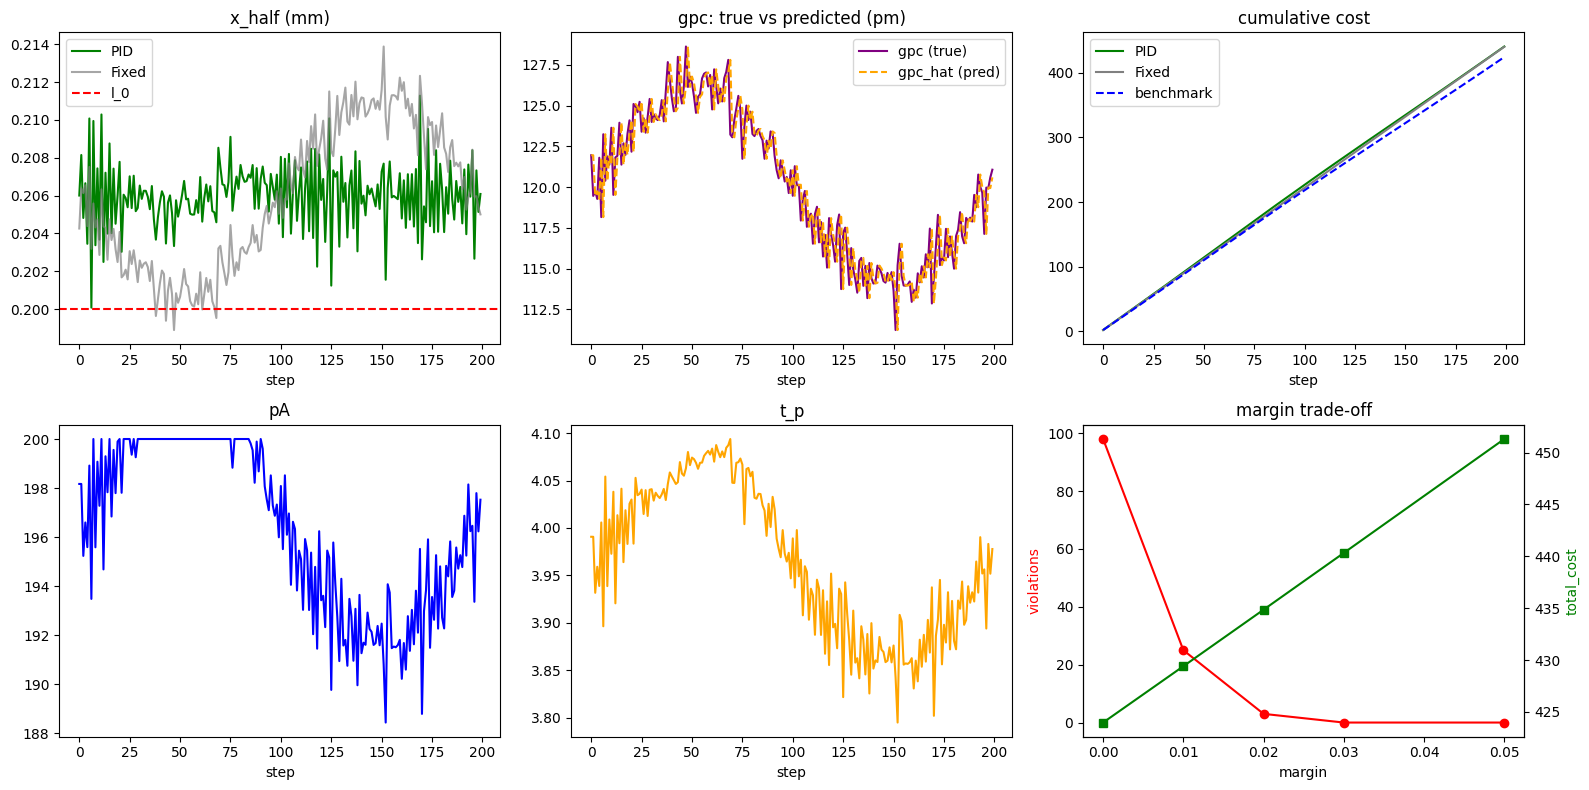

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
s = pid_df["step"]

# x_half vs 목표선
ax[0,0].plot(s, pid_df["x_half"]*1e3, color="green", label="PID")
ax[0,0].plot(s, fix_df["x_half"]*1e3, color="gray", alpha=.7, label="Fixed")
ax[0,0].axhline(l_0*1e3, ls="--", color="red", label="l_0")
ax[0,0].set_title("x_half (mm)"); ax[0,0].legend()

# gpc 실제 vs 예측
ax[0,1].plot(s, pid_df["gpc"]*1e12, color="purple", label="gpc (true)")
ax[0,1].plot(s, pid_df["gpc_hat"]*1e12, color="orange", ls="--", label="gpc_hat (pred)")
ax[0,1].set_title("gpc: true vs predicted (pm)"); ax[0,1].legend()

# 누적 cost
ax[0,2].plot(s, pid_df["total"], color="green", label="PID")
ax[0,2].plot(s, fix_df["total"], color="gray", label="Fixed")
ax[0,2].plot(s, mpc_df["total"], color="blue", ls="--", label="benchmark")
ax[0,2].set_title("cumulative cost"); ax[0,2].legend()

# pA, t_p
ax[1,0].plot(s, pid_df["pA"], color="blue");  ax[1,0].set_title("pA")
ax[1,1].plot(s, pid_df["t_p"], color="orange"); ax[1,1].set_title("t_p")

# margin 스윕
ax[1,2].plot(sweep["margin"], sweep["violations"], "o-", color="red")
ax[1,2].set_xlabel("margin"); ax[1,2].set_ylabel("violations", color="red")
axb = ax[1,2].twinx()
axb.plot(sweep["margin"], sweep["total_cost"], "s-", color="green")
axb.set_ylabel("total_cost", color="green")
ax[1,2].set_title("margin trade-off")

for a in ax.flat:
    if a.get_xlabel() == "": a.set_xlabel("step")
plt.tight_layout(); plt.show()